## 1. Import Necessary Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## 2. Data Collection

In [2]:
college_data = pd.read_csv("college_list.csv")
college_data.head()

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9


## 3. Data Understanding

In [4]:
college_data.shape

(500, 6)

In [5]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

In [5]:
college_data.describe()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


## 4. Data Preparation

### 4.1 Delete Unnecessary Features

In [3]:
x = college_data.drop("College_Name", axis=1)
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


## 4.2 Applying Data Transformation Techniques

In [4]:
from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()
scaled_x=std_scaler.fit_transform(x)
scaled_x=pd.DataFrame(scaled_x)
scaled_x

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [12]:
scaled_x.mean().round(4),scaled_x.std().round(4)

(0    0.0
 1    0.0
 2   -0.0
 3    0.0
 4   -0.0
 dtype: float64,
 0    1.001
 1    1.001
 2    1.001
 3    1.001
 4    1.001
 dtype: float64)

## 5. Model Building - Build Cluster algorithm

In [5]:
new_clusters=KMeans(n_clusters=3,random_state=12)
new_clusters.fit(scaled_x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",12
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 5)","[

In [6]:
new_clusters.labels_

array([2, 0, 0, 0, 2, 1, 1, 0, 2, 1, 1, 1, 0, 2, 1, 1, 2, 0, 1, 2, 1, 2,
       2, 0, 1, 1, 2, 0, 0, 0, 0, 1, 1, 2, 2, 1, 1, 0, 2, 1, 1, 1, 1, 0,
       1, 0, 2, 0, 1, 2, 2, 1, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 1, 0, 2, 0,
       1, 1, 2, 0, 2, 1, 0, 0, 1, 2, 1, 0, 0, 2, 1, 2, 0, 1, 1, 1, 1, 2,
       2, 2, 2, 1, 1, 0, 0, 1, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 0, 1, 2, 2,
       0, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 1, 2, 2, 2, 0, 2, 2, 1, 0, 0, 0,
       0, 0, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 1, 0, 0, 2, 2, 0, 0, 2, 0, 0,
       0, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 2, 2, 2, 1, 2, 0, 0, 1, 2, 2, 1, 2, 2, 2, 0, 2, 0, 2,
       2, 2, 1, 1, 1, 2, 1, 2, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 2, 0, 1,
       1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 1, 0, 1, 1, 2, 0, 1, 0, 0, 2, 2,
       0, 0, 2, 2, 1, 2, 2, 0, 1, 0, 1, 1, 0, 2, 0, 1, 1, 1, 2, 2, 0, 1,
       1, 0, 2, 1, 0, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 0, 1, 1, 1, 2, 2,
       1, 2, 0, 0, 1, 0, 1, 0, 2, 2, 1, 0, 0, 1, 2,

### Clustering is DONE here. Let's put this back to the original Dataset for further Data Mining Operations

### ============================================================

## LEVEL 2: Attach Clusters to Dataset

In [7]:
college_data["College_Level"] = new_clusters.labels_
college_data.head(10)

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,2
5,Government College of Technology Coimbatore - ...,28,226582,45,9.32,4,1
6,SSN College of Engineering - Campus 1,14,195983,93,4.51,3,1
7,SRM Institute of Science and Technology - Camp...,26,220103,88,8.33,9,0
8,VIT Vellore - Campus 1,18,249798,69,6.94,9,2
9,SASTRA University - Campus 1,18,168429,95,7.73,4,1


### Finding Cluster Centroids

In [17]:
new_clusters.cluster_centers_

array([[ 0.80005965, -0.35292454,  0.06058015, -0.06989436,  0.7879027 ],
       [ 0.33899088,  0.07714374,  0.32735611,  0.04780598, -1.0553563 ],
       [-0.9460557 ,  0.21270177, -0.34396936,  0.0127609 ,  0.32235082]])

In [18]:
x.head(10)

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
5,28,226582,45,9.32,4
6,14,195983,93,4.51,3
7,26,220103,88,8.33,9
8,18,249798,69,6.94,9
9,18,168429,95,7.73,4


In [9]:
x["College_Level"] = new_clusters.labels_
x.head(10)

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,14,113042,59,9.20,8,2
1,27,115999,67,3.07,7,0
2,22,47955,50,3.40,9,0
3,18,67841,43,4.64,8,0
4,15,100640,54,4.66,9,2
5,28,226582,45,9.32,4,1
6,14,195983,93,4.51,3,1
7,26,220103,88,8.33,9,0
8,18,249798,69,6.94,9,2
9,18,168429,95,7.73,4,1


### Note: This is the Most Important Data Mining Step post Clustering, but before we give labels

In [10]:
x.groupby(by='College_Level').agg(['mean'])

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
,mean,mean,mean,mean,mean
College_Level,,,,,
0,23.425676,116224.283784,70.040541,6.787973,7.554054
1,20.347305,143690.473054,74.622754,7.131078,3.862275
2,11.767568,152347.848649,63.091892,7.028919,6.621622


In [11]:
x.groupby(by="College_Level").agg(['min','max'])

Student_Faculty_Ratio     Annual_Fees_INR          \
                                min max             min     max   
College_Level                                                     
0                                14  29           30404  249536   
1                                 8  29           31605  248803   
2                                 8  22           31015  249930   

              Placement_Percentage     Average_Package_LPA         \
                               min max                 min    max   
College_Level                                                       
0                               40  99                2.00  11.99   
1                               40  99                2.01  11.96   
2                               40  99                2.01  11.91   

              Infrastructure_Score      
                               min max  
College_Level                           
0                                5   9  
1                                3   6  
2                                3   9

In [12]:
cluster_names = {0: "Best Colleges",
                 1: "Mid-Level Colleges",
                 2: "Emerging / Lower-Level Colleges"}

x["Category"] = x["College_Level"].map(cluster_names)

In [13]:
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level,Category
0,14,113042,59,9.20,8,2,Emerging / Lower-Level Colleges
1,27,115999,67,3.07,7,0,Best Colleges
2,22,47955,50,3.40,9,0,Best Colleges
3,18,67841,43,4.64,8,0,Best Colleges
4,15,100640,54,4.66,9,2,Emerging / Lower-Level Colleges
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,2,Emerging / Lower-Level Colleges
496,12,39111,76,3.62,7,2,Emerging / Lower-Level Colleges
497,16,199182,64,3.88,3,1,Mid-Level Colleges
498,10,46389,77,9.31,6,2,Emerging / Lower-Level Colleges


### ============================================================

## LEVEL 3: Now it's time to Transition to Supervised Learning

### The End!!

### ============================================================

# THE MISSED QUESTION...

### But, how to decide the Optimal Number of Clusters?

In [14]:
new_clusters = KMeans(n_clusters=3, random_state=12)
new_clusters.fit(scaled_x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",12
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 5)","[

In [15]:
new_clusters.inertia_

1854.1348733872487

#### The K-means algorithm aims to choose centroids that minimise the inertia, or within-cluster sum-of-squares criterion:

In [16]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i, random_state=12)
    kmeans.fit(scaled_x)
    wcss.append(kmeans.inertia_)
    

In [17]:
scaled_x

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [18]:
wcss

[2500.0,
 2111.6087292891193,
 1854.1348733872487,
 1636.7574013848734,
 1488.344906806164,
 1352.116491745796,
 1287.4071820563242,
 1217.4409847539484,
 1143.4668554152536,
 1079.2613750320543]

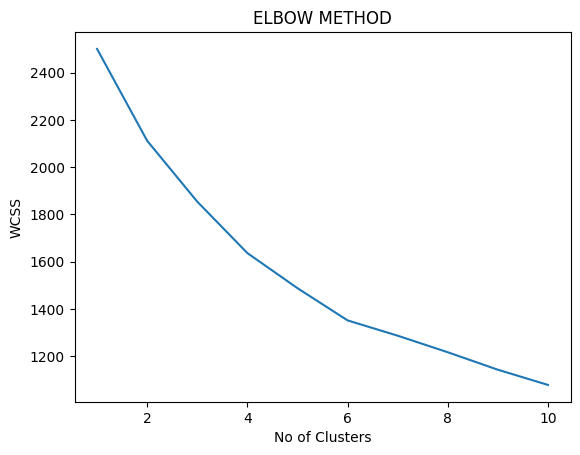

In [19]:
plt.plot(range(1,11),wcss)
plt.title('ELBOW METHOD')
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')
plt.show()

### Task:

1. Silhoutee Score
2. calinski harabasz score
3. IRIS Dataset - apply this clustering techniques and check

## 1.Silhoutee Score

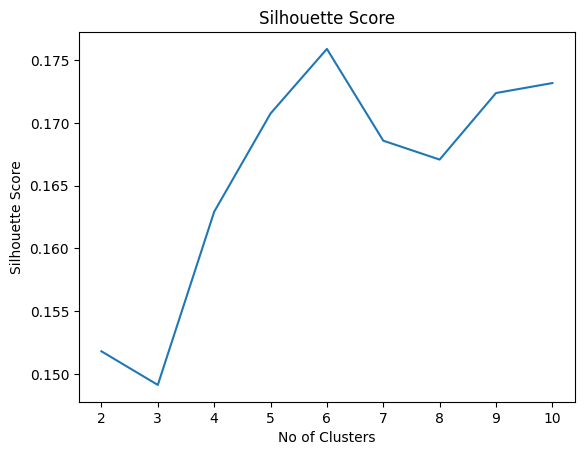

In [21]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i,random_state=12)
    labels = kmeans.fit_predict(scaled_x)
    score = silhouette_score(scaled_x,labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores)
plt.title("Silhouette Score")
plt.xlabel("No of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

# THE END!